In [1]:
import numpy as np
from sklearn.cluster import KMeans

c:\Python312\Lib\site-packages\sklearn\utils\__init__.py:16: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  from scipy.sparse import issparse


In [2]:
from sklearn.datasets import make_blobs
np.random.seed(42)
X, y = make_blobs(n_samples=600, centers=7, n_features=2, random_state=42)

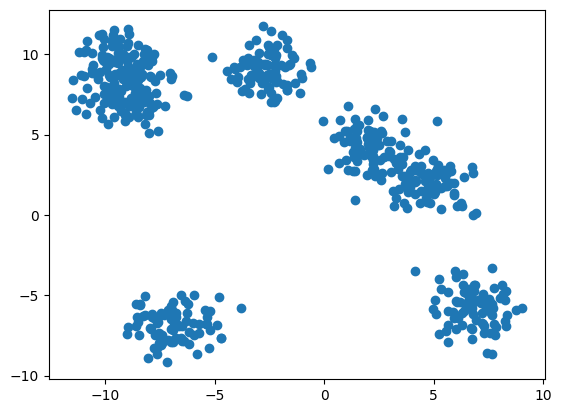

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])

In [4]:
#tree structure

class HKMnode:
    def __init__(self, centroids=None, children=None, leaf=True, points=None, indices=None):
        self.centroids = centroids
        self.children = children or []
        self.points = points
        self.leaf = leaf
        self.indices = indices

In [5]:
#indexing

def hierarchicalIndexing(data, indices, branching_factor, level, max_level, min_points):
    if data.shape[0] < min_points or level == max_level:
        leaf = HKMnode(points = data, indices=indices, leaf=True)
        return leaf
    
    kmeans = KMeans(n_clusters=branching_factor, random_state=42).fit(data)

    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    
    node = HKMnode(centroids=centroids, leaf=False)

    for i in range(branching_factor):
        points_in_cluster = data[labels == i]
        idx_in_cluster = indices[labels == i]
        child = hierarchicalIndexing(
            points_in_cluster,
            idx_in_cluster,
            branching_factor,
            level + 1,
            max_level,
            min_points
        )
        node.children.append(child)
    
    return node


    

In [6]:
# Searching
# class HKMnode:
#     def __init__(self, centroids=None, children=None, leaf=True, points=None):
#         self.centroids = centroids
#         self.children = children or []
#         self.points = points
#         self.leaf = leaf
def find_nearest_neighbor(node, point, return_index = False):

    norm_sq_point = point @ point
    if(node.leaf == True):
        # go through the points, find the closest one
        distances = []
        for i in range(node.points.shape[0]):
            neighbor = node.points[i]
            neighbor_sq = neighbor @ neighbor
            dist = norm_sq_point + neighbor_sq - 2 * (point @ neighbor)
            distances.append(dist)
        
        idx = distances.index(min(distances))
        if(return_index):
            return (node.points[idx], node.indices[idx])
        return node.points[idx]
            
    
    #go through the centroids and pass the closes to the find_cluster
    distance_to_centroids = []
    for i in range(node.centroids.shape[0]):
        centroid = node.centroids[i]
        centroid_sq = centroid @ centroid
        dist = norm_sq_point + centroid_sq - 2 * (point @ centroid)
        distance_to_centroids.append(dist)
    
    idx = distance_to_centroids.index(min(distance_to_centroids))
    closest_cluster = node.children[idx]

    return find_nearest_neighbor(closest_cluster, point, return_index)
    
def find_nearest_neighbor_i(node, point):

    query = np.asarray(point).reshape(-1)

    if(node.leaf == True):
        dot_prods =  node.points @ query
        idx = np.argmax(dot_prods)

        return(node.indices[idx])
    
    dot_prods = node.centroids @ query
    idx = np.argmax(dot_prods)

    return find_nearest_neighbor_i(node.children[idx], query)


def do_full_scan(all_points, query):
    
    dists = all_points @ query.T

    return np.argmax(dists)
    

In [7]:
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)
query = np.array([-11, -3])
query = query / np.linalg.norm(query)

root2 = hierarchicalIndexing(X_norm, np.arange(X_norm.shape[0]),1, 0, 1, 1)
root = hierarchicalIndexing(X_norm, np.arange(X_norm.shape[0]), 3,0, 5, 3)

In [8]:


import time

t1 = time.perf_counter()
res = find_nearest_neighbor_i(root, query)
t1 = time.perf_counter() - t1

t2 = time.perf_counter()
res_fs = find_nearest_neighbor_i(root2, query)
t2 = time.perf_counter() - t2

print("Time to do HKM: %.4fms \nTime to do full scan: %.4fms" %(t1 * 1000, t2 * 1000))

Time to do HKM: 0.1832ms 
Time to do full scan: 0.0874ms


IndexError: invalid index to scalar variable.

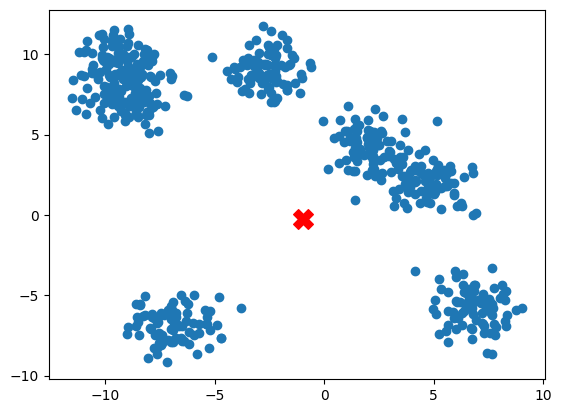

In [9]:
res_i = find_nearest_neighbor_i(root, query)
#res_i = X[res_i[1]]


plt.scatter(X[:, 0], X[:, 1])
plt.scatter(query[0], query[1], color='red', marker='X', s=200, label='Query')
plt.scatter(res_i[0], res_i[1], color='black', marker='P', s=200, label='Result')
plt.scatter(res_fs[0], res_fs[1], color='grey', marker='P', s=200, label='Result_fs')
plt.legend()
plt.show()

In [9]:
def read_fvecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    # all rows, skip the first col because it stores the number of dimensions
    return data[:, 1:].view(np.float32)

def read_ivecs(path):
    data = np.fromfile(path, dtype=np.int32)
    d = data[0]
    data = data.reshape(-1, d+1)
    
    return(data[:, 1:])


In [10]:
path_to_base = "./data/sift_base.fvecs"
path_to_queries = "./data/sift_query.fvecs"
path_to_gt = "./data/sift_groundtruth.ivecs"
paths = [
    "./data/small/siftsmall_base.fvecs",
    "./data/small/siftsmall_query.fvecs",
    "./data/small/siftsmall_groundtruth.ivecs"
]

base = read_fvecs(paths[0])
queries = read_fvecs(paths[1])
ground_truths = read_ivecs(paths[2])




In [11]:
base_large = read_fvecs(path_to_base)
query_large = read_fvecs(path_to_queries)
ground_truths_large = read_ivecs(path_to_gt)



In [12]:
#normalizing the data

base_large_normalized = base_large / np.linalg.norm(base_large, axis=1, keepdims=True)
query_large_normalized = query_large / np.linalg.norm(query_large, axis=1, keepdims=True)

In [13]:
base_large_normalized.shape

(1000000, 128)

# This is the same testing environment but we performe a full linear scan.

In [25]:



results1 = []
idx = np.random.choice(query_large_normalized.shape[0], size = 2000, replace=False)
query_samples = query_large_normalized[idx]
ground_truths_large_sample = ground_truths_large[idx]# idx
#print(idx.shape)
num_queries_large = query_samples.shape[0]



t = time.perf_counter()

t = time.perf_counter() - t
print()
accurate_count = 0
accurate_count_top_5 = 0
results = np.empty(num_queries_large, dtype=np.int32)
cosine_similarity_hkm = []
cosine_similarity_gt = []

t3 = time.perf_counter()
for q_id in range(num_queries_large):
    #print(q_id)
    q = query_samples[q_id]
    results[q_id] = do_full_scan(base_large_normalized, q)
    # res = find_nearest_neighbor_i(root4, q)

    # true_results_idx = ground_truths_large_sample[q_id][0]
    

    # if(res == true_results_idx):
    #     accurate_count += 1
    # cos_hkm = base_large_normalized[res] @ q
    # cos_gt = base_large_normalized[true_results_idx] @ q

    # cosine_similarity_hkm.append(cos_hkm)
    # cosine_similarity_gt.append(cos_gt)

t3 = time.perf_counter() - t3

for q_id in range(num_queries_large):

    q = query_samples[q_id]            
    res = results[q_id]
    true_results_idx = ground_truths_large_sample[q_id]
    if(res == true_results_idx[0]):
        accurate_count += 1
    
    for i in range(5):
        if(res == true_results_idx[i]):
            accurate_count_top_5 += 1


    cos_hkm = base_large_normalized[res] @ q
    cos_gt = base_large_normalized[true_results_idx[0]] @ q
    cosine_similarity_hkm.append(cos_hkm)
    cosine_similarity_gt.append(cos_gt)
    

recall = accurate_count / num_queries_large
recall5 = accurate_count_top_5 / num_queries_large
mean_cos_hkm = np.mean(cosine_similarity_hkm)
mean_cos_gt = np.mean(cosine_similarity_gt)
mean_gap = mean_cos_gt - mean_cos_hkm

print("max_depth: ", 0, " branching factor: ", 0)
print("Recall1", recall)
print("Recall5", recall5)
print("Time to answer queries: ", t3/num_queries_large)
print("Time to train: ", t)
print("Mean GT cosine: ", mean_cos_gt)
print("Mean HKM cosine: ", mean_cos_hkm)

results1.append({
    "max_depth": 0,
    "brancing_factor": 0,
    "recall": recall,
    "recall5": recall5,
    "train_time": t,
    "query_time": t3 / num_queries_large,
    "mean_cos_hkm": mean_cos_hkm,
    "mean_cos_gt": mean_cos_gt,
    "mean_gap": mean_gap
})


max_depth:  0  branching factor:  0
Recall1 0.978
Recall5 1.0
Time to answer queries:  0.018812214199977462
Time to train:  5.549995694309473e-05
Mean GT cosine:  0.9267732
Mean HKM cosine:  0.92677414


-- Recall 1 can never be 1 if mean GT cosine != 1.

In [61]:



results1 = []
idx = np.random.choice(query_large_normalized.shape[0], size = 1000, replace=False)
query_samples = query_large_normalized[idx]
ground_truths_large_sample = ground_truths_large[idx]# idx
#print(idx.shape)
num_queries_large = query_samples.shape[0]

max_depths = [1] #4 
brancing_factors = [1] #2

for md in max_depths:
    for bf in brancing_factors:
        t = time.perf_counter()

        root4 = hierarchicalIndexing(base_large_normalized, np.arange(base_large_normalized.shape[0]),
                            bf,
                              0,
                            md,
                            100)
        t = time.perf_counter() - t
        print()
        accurate_count = 0
        accurate_count_top_5 = 0
        results = np.empty(num_queries_large, dtype=np.int32)
        cosine_similarity_hkm = []
        cosine_similarity_gt = []

        t3 = time.perf_counter()
        for q_id in range(num_queries_large):
            #print(q_id)
            q = query_samples[q_id]
            results[q_id] = find_nearest_neighbor_i(root4, q)
            # res = find_nearest_neighbor_i(root4, q)

            # true_results_idx = ground_truths_large_sample[q_id][0]
            

            # if(res == true_results_idx):
            #     accurate_count += 1
            # cos_hkm = base_large_normalized[res] @ q
            # cos_gt = base_large_normalized[true_results_idx] @ q

            # cosine_similarity_hkm.append(cos_hkm)
            # cosine_similarity_gt.append(cos_gt)

        t3 = time.perf_counter() - t3

        for q_id in range(num_queries_large):

            q = query_samples[q_id]            
            res = results[q_id]
            true_results_idx = ground_truths_large_sample[q_id]
            if(res == true_results_idx[0]):
                accurate_count += 1
            
            for i in range(5):
                if(res == true_results_idx[i]):
                    accurate_count_top_5 += 1


            cos_hkm = base_large_normalized[res] @ q
            cos_gt = base_large_normalized[true_results_idx[0]] @ q
            cosine_similarity_hkm.append(cos_hkm)
            cosine_similarity_gt.append(cos_gt)
            

        recall = accurate_count / num_queries_large
        recall5 = accurate_count_top_5 / num_queries_large
        mean_cos_hkm = np.mean(cosine_similarity_hkm)
        mean_cos_gt = np.mean(cosine_similarity_gt)
        mean_gap = mean_cos_gt - mean_cos_hkm

        print("max_depth: ", md, " branching factor: ", bf)
        print("Recall1", recall)
        print("Recall5", recall5)
        print("Time to answer queries: ", t3/num_queries_large)
        print("Time to train: ", t)
        print("Mean GT cosine: ", mean_cos_gt)
        print("Mean HKM cosine: ", mean_cos_hkm)

        results1.append({
            "max_depth": md,
            "brancing_factor": bf,
            "recall": recall,
            "recall5": recall5,
            "train_time": t,
            "query_time": t3 / num_queries_large,
            "mean_cos_hkm": mean_cos_hkm,
            "mean_cos_gt": mean_cos_gt,
            "mean_gap": mean_gap
        })
    
    


max_depth:  1  branching factor:  1
Recall1 0.987
Recall5 1.0
Time to answer queries:  0.015472828400001163
Time to train:  3.7074156000016956
Mean GT cosine:  0.92666835
Mean HKM cosine:  0.9266688


In [45]:
import pandas as pd
df4 = pd.DataFrame(results1)

In [ ]:
#df4.to_pickle("hkm_results4.pkl")

In [ ]:
#df3 = pd.DataFrame(results1)
#df3.to_pickle("hkm_results3.pkl")

In [50]:
df1 = pd.read_pickle("hkm_results.pkl")
df2 = pd.read_pickle("hkm_results2.pkl")
df3 = pd.read_pickle("hkm_results3.pkl")
df4 = pd.read_pickle("hkm_results4.pkl")
# with md 1 and 2, go with much larger branching factor, even all they way up to 256! especially for md = 1
# Add the gound truth as well.

In [ ]:
#df2.to_pickle("hkm_results2.pkl")

In [52]:
df4

,max_depth,brancing_factor,recall,recall5,train_time,query_time,mean_cos_hkm,mean_cos_gt,mean_gap
0,1,2,0.987,1.000,3.817360,0.008423,0.928457,0.928457,-7.152557e-07
1,1,4,0.935,0.993,4.254254,0.005378,0.927651,0.928457,8.057952e-04
2,1,6,0.884,0.990,4.988896,0.002599,0.927046,0.928457,1.411140e-03
3,1,10,0.776,0.952,8.858047,0.001687,0.924911,0.928457,3.545463e-03
4,1,12,0.757,0.950,10.116874,0.001475,0.924647,0.928457,3.809631e-03
5,1,14,0.710,0.940,10.406024,0.001225,0.923579,0.928457,4.877687e-03
6,1,20,0.669,0.895,13.535016,0.000903,0.921693,0.928457,6.763697e-03


In [22]:
results1 = []
idx = np.random.choice(query_large.shape[0], size = 1000, replace=False)
query_samples = query_large[idx]
ground_truths_large_sample = ground_truths_large[idx]# idx
#print(idx.shape)
num_queries_large = query_samples.shape[0]

max_depths = [4] #4 
brancing_factors = [2] #2

for md in max_depths:
    for bf in brancing_factors:
        t = time.perf_counter()

        root4 = hierarchicalIndexing(base_large, np.arange(base_large.shape[0]),
                            bf,
                              0,
                            md,
                            100)
        t = time.perf_counter() - t
        print()
        accurate_count = 0

        t3 = time.perf_counter()
        for q_id in range(num_queries_large):
            #print(q_id)
            q = query_samples[q_id]
            res = find_nearest_neighbor(root4, q, return_index=True)

            true_results_idx = ground_truths_large_sample[q_id][0]
            

            if(res[1] == true_results_idx):
                accurate_count += 1
        t3 = time.perf_counter() - t3
        print("max_depth: ", md, " branching factor: ", bf)
        recall = accurate_count / num_queries_large
        print("Recall1", recall)
        print("Time to answer queries: ", t3)
        print("Time to train: ", t)

        results1.append({
            "max_depth": md,
            "brancing_factor": bf,
            "recall": recall,
            "train_time": t,
            "query_time": t3 / num_queries_large
        })


max_depth:  4  branching factor:  2
Recall1 0.734
Time to answer queries:  334.2826983000268
Time to train:  10.783827400009613


In [53]:
df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

In [54]:
df_all

,max_depth,brancing_factor,recall,recall5,train_time,query_time,mean_cos_hkm,mean_cos_gt,mean_gap
0,2,2,0.910,0.996,4.467640,0.003818,0.925624,0.926576,9.527802e-04
1,2,4,0.717,0.926,7.990856,0.001405,0.921775,0.926576,4.801750e-03
2,2,6,0.619,0.887,11.388675,0.000510,0.919970,0.926576,6.606817e-03
3,2,10,0.532,0.835,20.434686,0.000303,0.918626,0.926576,7.949948e-03
4,2,12,0.494,0.813,25.244631,0.000221,0.917405,0.926576,9.171903e-03
5,2,14,0.461,0.789,27.187906,0.000195,0.916503,0.926576,1.007372e-02
6,2,20,0.390,0.737,35.300041,0.000141,0.914330,0.926576,1.224673e-02
7,4,2,0.709,0.923,9.832011,0.001089,0.921676,0.926576,4.900813e-03
8,4,4,0.400,0.740,19.828889,0.000198,0.914133,0.926576,1.244348e-02
9,4,6,0.284,0.613,29.913007,0.000064,0.910202,0.926576,1.637429e-02


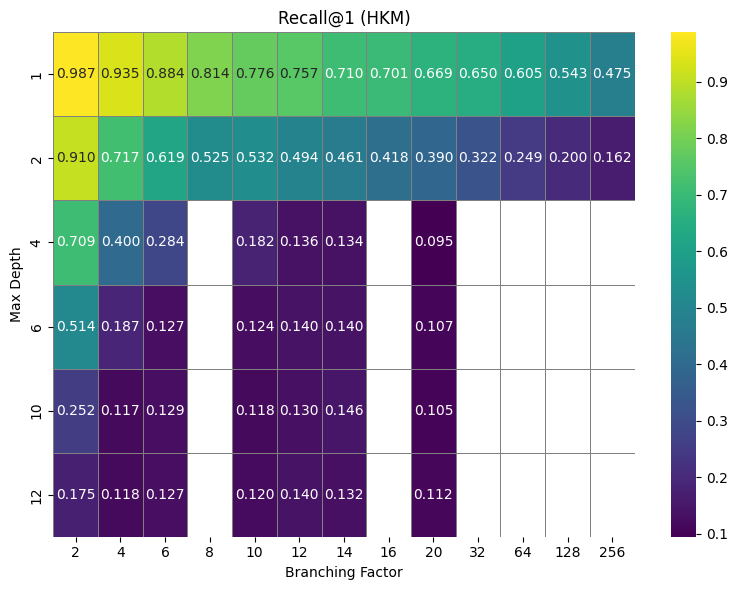

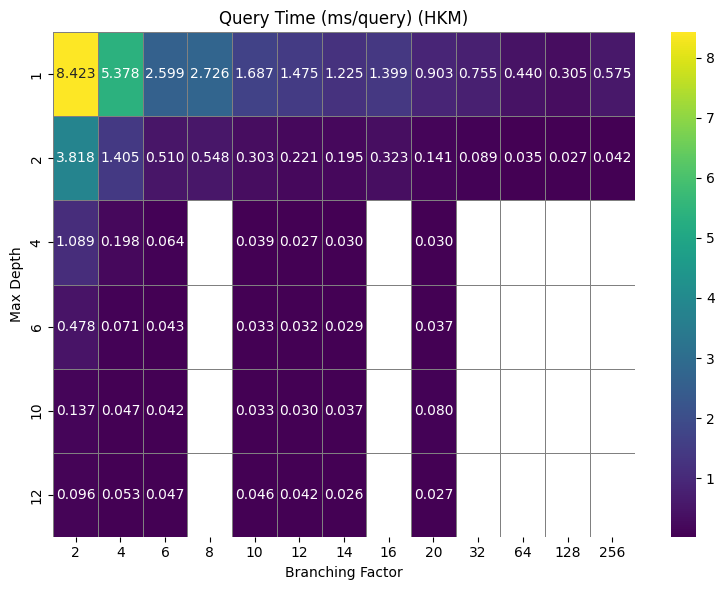

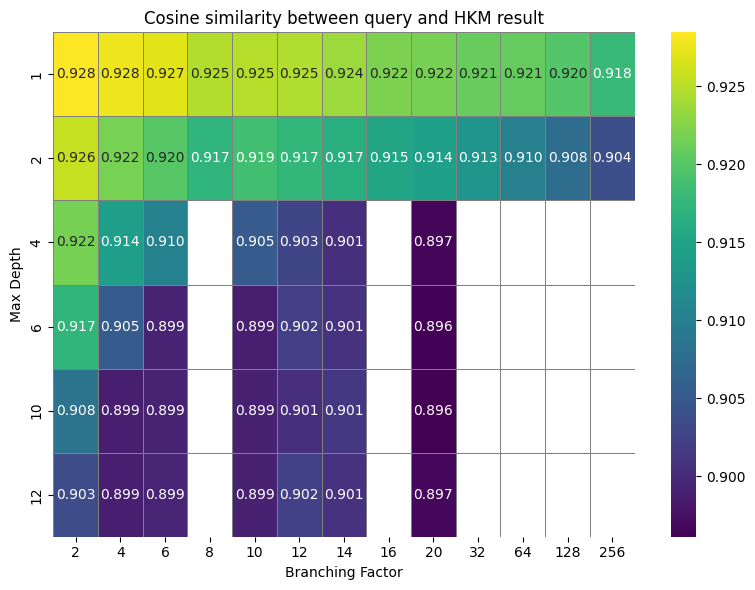

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

recall_matrix = df_all.pivot(index="max_depth",
                             columns="brancing_factor",
                             values="recall")

query_matrix = df_all.pivot(index="max_depth",
                            columns="brancing_factor",
                            values="query_time") * 1000  # convert to ms/query

cos_matrix = df_all.pivot(
    index="max_depth",
    columns="brancing_factor",
    values="mean_cos_hkm"
)



def plot_heatmap(matrix, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix,
                annot=True,
                fmt=".3f",
                cmap="viridis",
                linewidths=0.5,
                linecolor="gray")
    plt.title(title)
    plt.xlabel("Branching Factor")
    plt.ylabel("Max Depth")
    plt.tight_layout()
    plt.show()
plot_heatmap(recall_matrix, "Recall@1 (HKM)")
plot_heatmap(query_matrix, "Query Time (ms/query) (HKM)")
plot_heatmap(cos_matrix, "Cosine similarity between query and HKM result")

<function matplotlib.pyplot.show(close=None, block=None)>

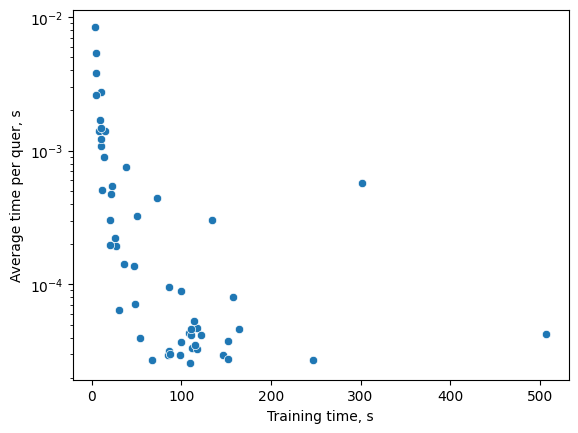

In [56]:
sns.scatterplot( x=df_all["train_time"], y = df_all["query_time"])
plt.yscale("log")

plt.xlabel("Training time, s")
plt.ylabel("Average time per quer, s")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

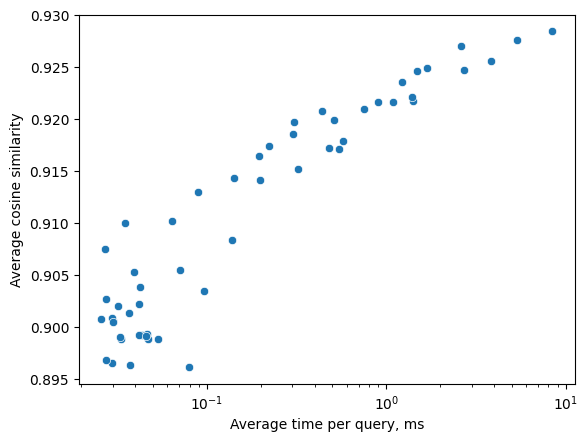

In [64]:
sns.scatterplot( y=df_all["mean_cos_hkm"], x = (df_all["query_time"])*1000)
plt.xscale("log")

plt.ylabel("Average cosine similarity")
plt.xlabel("Average time per query, ms")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

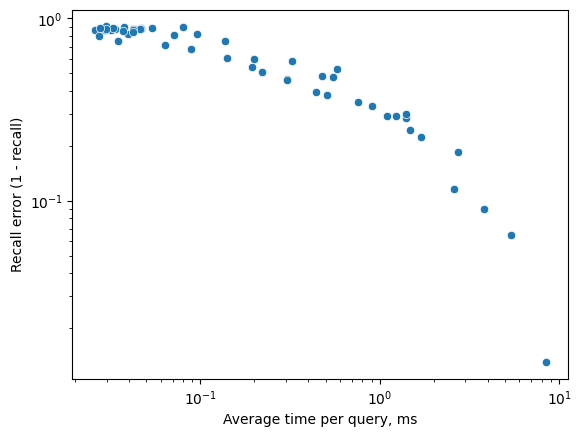

In [63]:
sns.scatterplot( y=(1 - df_all["recall"]), x = df_all["query_time"] * 1000)
plt.yscale("log")
plt.xscale("log")

plt.ylabel("Recall error (1 - recall)")
plt.xlabel("Average time per query, ms")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

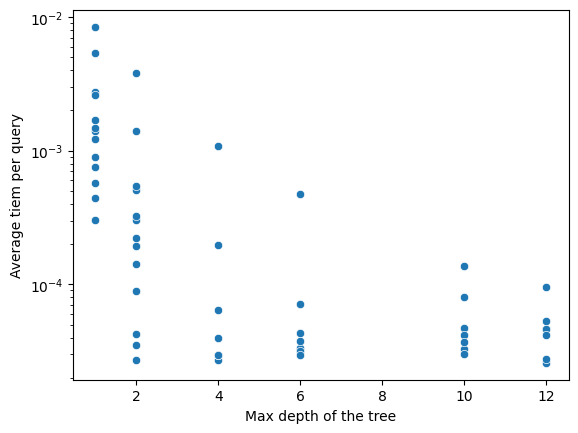

In [59]:
sns.scatterplot(x=df_all["max_depth"], y=df_all["query_time"])
plt.yscale("log")

plt.xlabel("Max depth of the tree")
plt.ylabel("Average tiem per query")
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

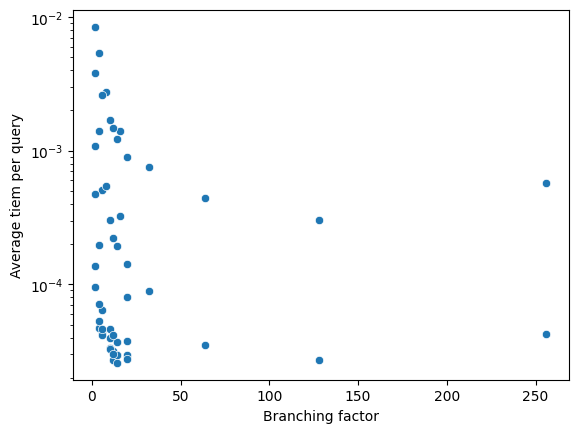

In [60]:
sns.scatterplot(x=df_all["brancing_factor"], y=df_all["query_time"])
plt.yscale("log")

plt.xlabel("Branching factor")
plt.ylabel("Average tiem per query")
plt.show


# hnswlib is installed on a different environment, import anything you will need.

I used the code snippet from
https://github.com/nmslib/hnswlib
to implement it.

In [11]:
import hnswlib
import pickle
import time

In [32]:
#ground_truths_large
#base_large_normalized
#query_large_normalized

dim = base_large_normalized.shape[1]
num_elements = base_large_normalized.shape[0]

cosine_sim = []

#index
p = hnswlib.Index(space='ip', dim=dim)


#init index
p.init_index(max_elements=num_elements, ef_construction=100, M=16)

p.set_ef(100)
#print("adding %d elements" % (len(data1)))
t0 = time.perf_counter()
p.add_items(base_large_normalized)
t0 = time.perf_counter() - t0
t = time.perf_counter()
labels, dists = p.knn_query(query_large_normalized, k=1, num_threads=-1)
t = time.perf_counter() - t


num_queries = query_large_normalized.shape[0]
count_accurate = 0
for q_id in range(num_queries):
    if labels[q_id][0] == ground_truths_large[q_id][0]:
        count_accurate += 1
    cosine_sim.append(base_large_normalized[labels[q_id][0]] @ query_large_normalized[q_id])

print("Recall :", count_accurate / num_queries)

print("Total time: ", t)
print("Time per query: ", t/num_queries)

print("Time to index: ", t0)

print("Average cosine similarity: ", np.mean(cosine_sim))
    

#print("recall:", np.mean(labels.reshape(-1) == np.arange(len(data1))), "\n")

Recall : 0.9757
Total time:  0.5872593999993114
Time per query:  5.872593999993114e-05
Time to index:  50.592326899997715
Average cosine similarity:  0.9270834
